In [27]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

In [28]:
# pip install numpy pandas scikit-learn

In [29]:
dataset = pd.read_csv('TSDcsv.csv')
dataset.head()

,Area,Standard deviation,max deflection,SCI200,SCI300,SCISUB,Temp Road,TSD Index
0,988.417667,182.268992,756.1037,58.7054,110.4476,175.5417,38.5587,100.009353
1,1305.167988,138.921647,844.2630,69.3978,105.2301,137.0152,38.3569,99.995496
2,1028.884310,183.548690,776.3429,60.5225,94.6360,164.7373,42.5451,99.995271
3,731.060382,214.611613,657.5752,114.0269,177.2713,127.7729,32.4979,99.987278
4,674.150422,214.851477,658.2326,147.7425,218.3060,97.9857,22.6152,99.979331


In [30]:
X = dataset.iloc[:, 0:7]
y = dataset.iloc[:,7]
X0= dataset.iloc[:,0]
X1= dataset.iloc[:,1]
X2= dataset.iloc[:,2]
X3= dataset.iloc[:,3]

In [31]:
X

,Area,Standard deviation,max deflection,SCI200,SCI300,SCISUB,Temp Road
0,988.417667,182.268992,756.1037,58.7054,110.4476,175.5417,38.5587
1,1305.167988,138.921647,844.2630,69.3978,105.2301,137.0152,38.3569
2,1028.884310,183.548690,776.3429,60.5225,94.6360,164.7373,42.5451
3,731.060382,214.611613,657.5752,114.0269,177.2713,127.7729,32.4979
4,674.150422,214.851477,658.2326,147.7425,218.3060,97.9857,22.6152
...,...,...,...,...,...,...,...
233770,19.544985,10.166246,28.0575,13.5364,17.5459,1.4284,10.8161
233771,15.142990,6.704875,19.7467,4.1035,7.5689,1.4267,21.1939
233772,67.641717,10.589245,52.9212,6.1410,11.1931,5.1773,7.8843
233773,24.309217,11.275609,33.3599,7.7109,13.9353,1.9799,13.0853


In [32]:
y

0         100.009353
1          99.995496
2          99.995271
3          99.987278
4          99.979331
             ...    
233770      0.005832
233771      0.004675
233772      0.003749
233773      0.003715
233774      0.003394
Name: TSD Index, Length: 233775, dtype: float64

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
regressor = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=0.8,
    max_features='sqrt',
    random_state=42
)

In [35]:

regressor.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [36]:
y_pred = regressor.predict(X_test)
np.set_printoptions(precision=2)

In [37]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.36652313995539504


In [38]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.9988450244325212

In [39]:
# param_grid = {
#     'n_estimators': [100, 200, 300, 400, 500],
#     'learning_rate': [0.01, 0.1],
#     'max_depth': [3, 4],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2],
#     'subsample': [0.8, 1.0],
#     'max_features': ['sqrt', 'log2', None]  # Removed 'auto' to avoid warning
# }

In [40]:
# grid_search = GridSearchCV(estimator=regressor, param_grid=param_grid,
                        #    cv=5, scoring='r2', n_jobs=1, verbose=2)


In [41]:
# grid_search.fit(X_train, y_train)

In [42]:
# print("Best Parameters:", grid_search.best_params_)

In [43]:
# regressor.predict([
#     # [2, 2.72, 78.7, 4.75, 50],
#     [2, 2.72, 71.6, 4.71, 50],
#     [3, 2.72, 86.3, 8.56, 50],
#     [2, 2.55, 71.6, 4.9, 50],
#     [2, 2.55, 78.7, 5.99, 110],
#     [1, 2.72, 71.6, 5.32, 110],
#     [3, 2.55, 71.6, 8.12, 50],
#     [3, 2.55, 78.7, 7.02, 75],
#     [2, 2.72, 86.3, 5.82, 90],
#     [1, 2.55, 78.7, 5.05, 50],
#     [2, 2.55, 71.6, 5.37, 50],
#     [2, 2.55, 86.3, 5.37, 35],
#     [2, 2.72, 71.6, 5.27, 75],
#     [3, 2.55, 86.3, 7.02, 50],
#     [2, 2.72, 86.3, 5.27, 90],
#     [3, 2.72, 86.3, 8.63, 25],
#     [2, 2.72, 71.6, 5.79, 50],
#     [2, 2.55, 86.3, 5.93, 35],
#     [1, 2.72, 71.6, 6.48, 75],
#     [1, 2.55, 86.3, 6.16, 35],
#     [2, 2.55, 71.6, 5.37, 90],
#     [2, 2.55, 71.6, 4.84, 35],
#     [3, 2.72, 71.6, 8.56, 90],
#     [1, 2.55, 71.6, 5.05, 75],
#     [3, 2.55, 78.7, 8.12, 75],
#     [1, 2.72, 86.3, 5.89, 75],
#     [2, 2.72, 86.3, 4.71, 50],
#     [2, 2.55, 86.3, 4.84, 35],
#     [1, 2.55, 86.3, 5.11, 110],
#     [2, 2.55, 78.7, 5.99, 90],
#     [3, 2.72, 86.3, 8.56, 75],
#     [1, 2.55, 71.6, 5.05, 35],
#     [1, 2.72, 86.3, 5.27, 35],
#     [1, 2.72, 86.3, 5.32, 35],
#     [1, 2.55, 71.6, 5.11, 90],
#     [1, 2.55, 71.6, 6.16, 75],
#     [2, 2.55, 86.3, 4.9, 110],
#     [2, 2.72, 71.6, 5.79, 90],
#     [1, 2.55, 78.7, 5.58, 75],
#     [3, 2.55, 86.3, 7.02, 25],
#     [3, 2.55, 86.3, 7.06, 90],
#     [1, 2.55, 78.7, 6.23, 35],
#     [1, 2.72, 78.7, 5.89, 35],
#     [1, 2.55, 71.6, 6.16, 50],
#     [3, 2.72, 78.7, 8.63, 75],
#     [2, 2.55, 71.6, 5.99, 75],
#     [3, 2.55, 71.6, 9.56, 35],
#     [1, 2.55, 71.6, 6.23, 50],
#     [2, 2.55, 86.3, 5.93, 110],
#     [2, 2.55, 78.7, 5.37, 50],
#     [3, 2.72, 71.6, 8.63, 90],
#     [3, 2.55, 86.3, 9.54, 35],
#     [1, 2.55, 86.3, 5.58, 110],
#     [1, 2.72, 71.6, 5.27, 90],
#     [3, 2.72, 86.3, 7.73, 75],
#     [3, 2.55, 71.6, 8.12, 25],
#     [3, 2.72, 78.7, 8.63, 25],
#     [1, 2.72, 71.6, 6.48, 35],
#     [1, 2.55, 86.3, 5.58, 35],
#     [3, 2.72, 78.7, 8.63, 90],
#     [2, 2.55, 86.3, 5.37, 90],
#     [3, 2.72, 86.3, 7.39, 35],
#     [1, 2.55, 78.7, 6.23, 75],
#     [3, 2.72, 86.3, 8.56, 90],
#     [1, 2.72, 71.6, 5.27, 75],
#     [1, 2.72, 78.7, 5.27, 50],
#     [3, 2.72, 78.7, 8.63, 50],
#     [1, 2.55, 78.7, 5.58, 50],
#     [3, 2.55, 86.3, 8.12, 25],
#     [3, 2.55, 71.6, 7.06, 90],
#     [1, 2.55, 78.7, 6.23, 110],
#     [1, 2.55, 86.3, 5.58, 90],
#     [3, 2.55, 78.7, 9.56, 50],
#     [1, 2.72, 86.3, 5.89, 50],
#     [3, 2.72, 86.3, 8.63, 90],
#     [1, 2.72, 86.3, 6.5, 110],
#     [1, 2.55, 86.3, 5.05, 90],
#     [2, 2.72, 86.3, 4.71, 35],
#     [3, 2.55, 71.6, 9.56, 50],
#     [2, 2.72, 71.6, 5.82, 110],
#     [2, 2.55, 71.6, 5.99, 90],
#     [2, 2.55, 71.6, 4.84, 50],
#     [1, 2.72, 71.6, 5.32, 75],
#     [1, 2.72, 78.7, 6.5, 75],
#     [1, 2.55, 71.6, 5.05, 90],
#     [3, 2.55, 86.3, 8.12, 35],
#     [2, 2.55, 78.7, 4.84, 110],
#     [2, 2.72, 78.7, 5.27, 50],
#     [1, 2.55, 86.3, 5.11, 90],
#     [3, 2.72, 86.3, 7.78, 75]
# ]
# )

In [44]:
import pickle
with open('TSDgbr.pkl', 'wb') as f:
    pickle.dump(regressor, f)

In [45]:
# !pip install seaborn

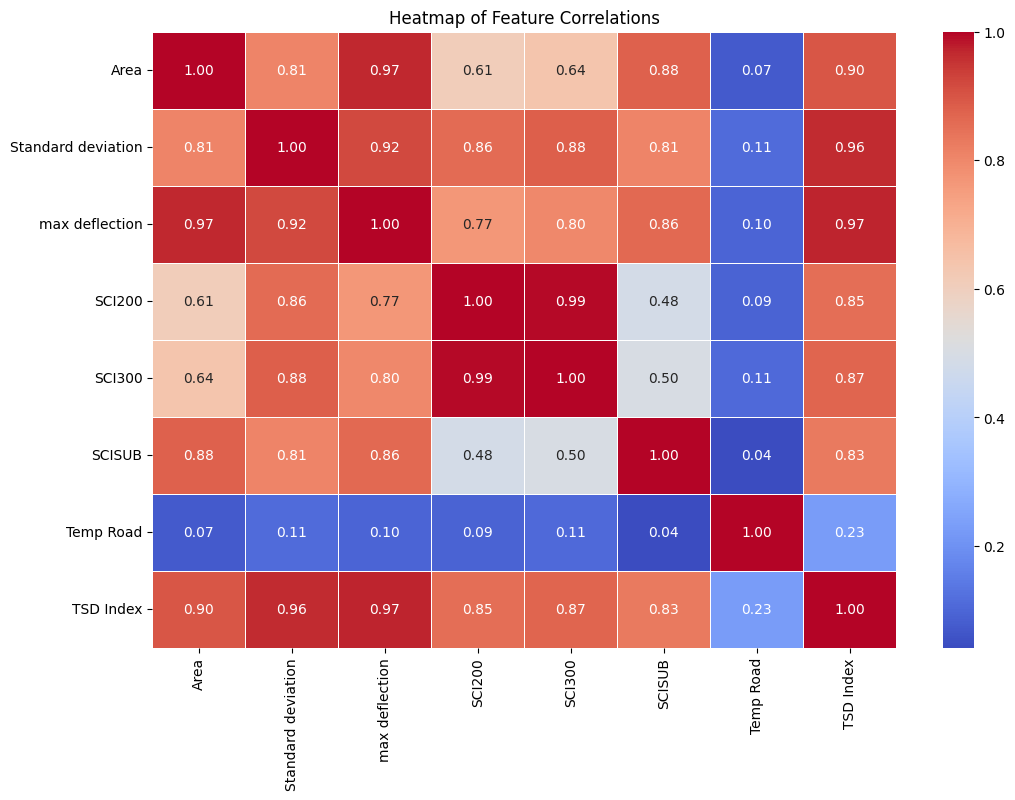

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
correlation_matrix =dataset.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Feature Correlations")
plt.show()


c:\Users\hp\Desktop\TSD ML\TSD ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|===================| 186935/187020 [117:20<00:03]        

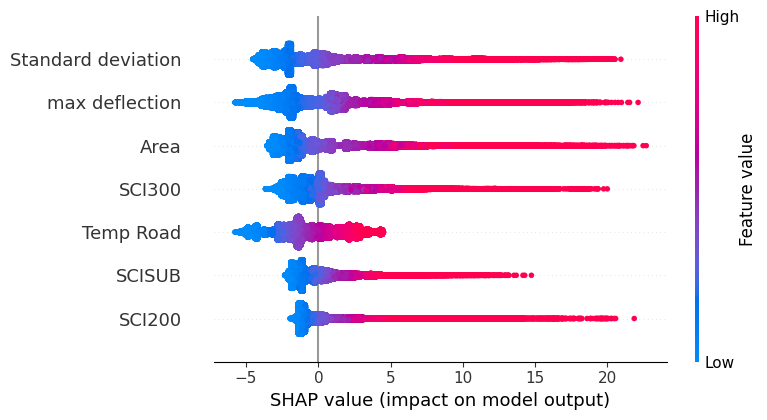

In [47]:

import shap

# Create SHAP explainer and compute values
explainer = shap.Explainer(regressor, X_train)
shap_values = explainer(X_train)

# Plot SHAP summary
shap.summary_plot(shap_values, X_train)




In [48]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

def regression_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return {
        "R2": r2,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE (%)": mape
    }

# Example usage
y_pred = regressor.predict(X_test)
metrics = regression_metrics(y_test, y_pred)

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


R2: 0.9988
MSE: 0.3665
RMSE: 0.6054
MAPE (%): 4.8964
